In [39]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**EXTRAÇÃO DE DADOS**

In [2]:
url = 'https://raw.githubusercontent.com/SandraRojasZ/Pos_Tech_Data_Analytics/main/Base_de_Dados/SementesAbobora.xlsx'

In [3]:
df = pd.read_excel(url)

In [4]:
df.head(3)

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,(A) Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,(A) Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,(A) Çerçevelik


In [5]:
df.shape

(2500, 13)

In [6]:
from sklearn.utils import shuffle

In [12]:
# para embaralhas os dados, principalmente dos dados da Class que estavam ordenados
df = shuffle(df)

In [9]:
# Mostra que não há um grande desbalanceamento de Classes, assim não será um problema para os modelos de ML
df['Class'].value_counts()

,count
Class,
(A) Çerçevelik,1300
(B) Ürgüp Sivrisi,1200


In [10]:
df['Class'].unique()

array(['(A) Çerçevelik ', '(B) Ürgüp Sivrisi'], dtype=object)

In [11]:
df['Class'].nunique()

2

Análise Exploratória

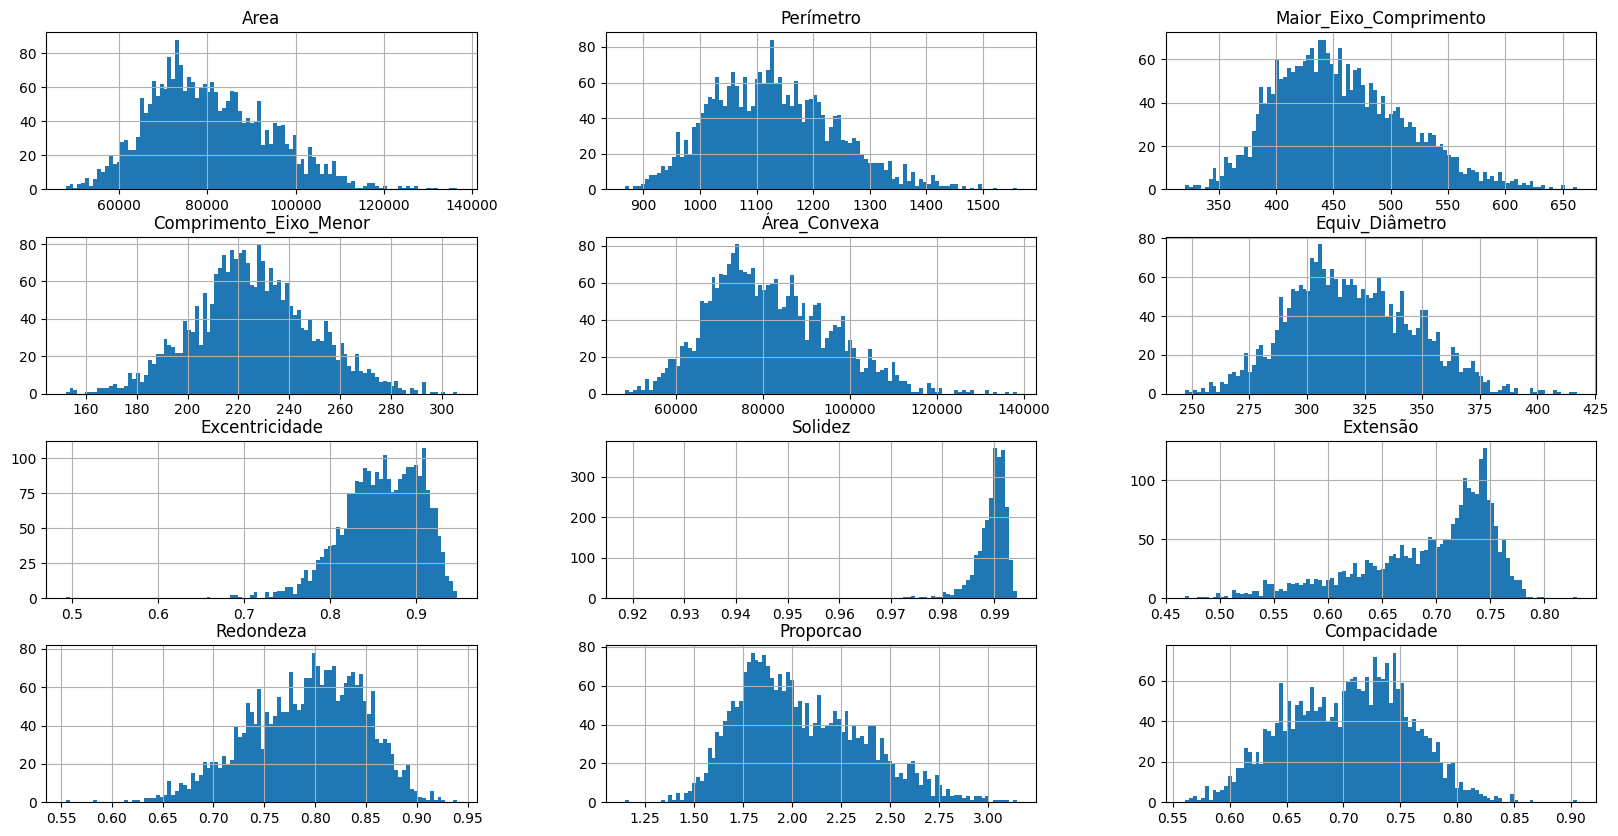

In [17]:
df.hist(bins=100, figsize=(20,10))
plt.show()

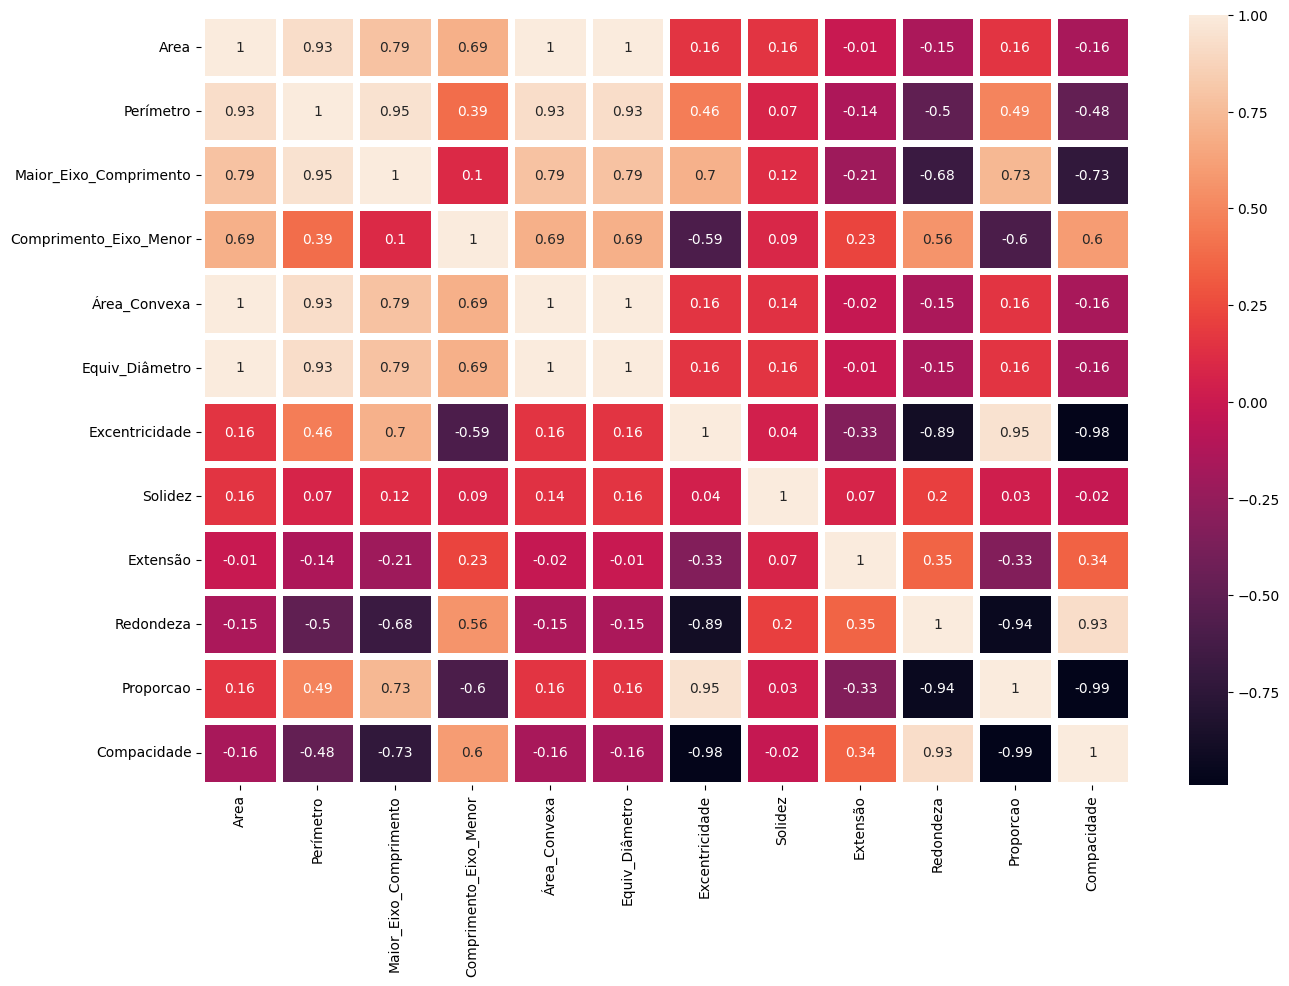

In [19]:
correlation_matrix = df.corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=5, ax=ax)
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le = LabelEncoder()
df.Class = le.fit_transform(df['Class'])

In [22]:
set(df['Class'])

{0, 1}

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 1142 to 459
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    2500 non-null   int64  
 1   Perímetro               2500 non-null   float64
 2   Maior_Eixo_Comprimento  2500 non-null   float64
 3   Comprimento_Eixo_Menor  2500 non-null   float64
 4   Área_Convexa            2500 non-null   int64  
 5   Equiv_Diâmetro          2500 non-null   float64
 6   Excentricidade          2500 non-null   float64
 7   Solidez                 2500 non-null   float64
 8   Extensão                2500 non-null   float64
 9   Redondeza               2500 non-null   float64
 10  Proporcao               2500 non-null   float64
 11  Compacidade             2500 non-null   float64
 12  Class                   2500 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 273.4 KB


In [24]:
df.columns

Index(['Area', 'Perímetro', 'Maior_Eixo_Comprimento', 'Comprimento_Eixo_Menor',
       'Área_Convexa', 'Equiv_Diâmetro', 'Excentricidade', 'Solidez',
       'Extensão', 'Redondeza', 'Proporcao', 'Compacidade', 'Class'],
      dtype='object')

**Separação das variáveis**

In [26]:
X = df[['Area', 'Perímetro', 'Comprimento_Eixo_Menor', 'Excentricidade', 'Solidez', 'Extensão', 'Redondeza', 'Proporcao', 'Compacidade']]
y = df['Class']

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Normalização ou Padronização

In [31]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [36]:
X_train

array([[-0.76721046, -0.71140485, -0.6923175 , ...,  0.07683422,
         0.01679793, -0.144769  ],
       [-1.02998751, -1.30694889, -0.07365936, ...,  1.17865952,
        -1.09046937,  1.15635187],
       [-0.46712241, -0.78399395,  0.29208062, ...,  1.13260251,
        -0.91912535,  0.9567588 ],
       ...,
       [-0.66836905, -0.64005471, -0.67100985, ...,  0.13883404,
         0.08716573, -0.19372579],
       [ 0.260042  ,  0.36353885,  0.14702765, ..., -0.32882172,
         0.08464133, -0.2539803 ],
       [ 0.67591778,  1.10392402, -0.53682472, ..., -1.23401903,
         1.5292323 , -1.42706033]])

In [35]:
X_train.shape

(1750, 9)

In [37]:
X_test.shape

(750, 9)

In [38]:
type(y_train)

pandas.core.series.Series

In [40]:
# reshape molda a matriz sem alterar os dados da matriz
y_train = np.asarray(y_train).astype('float32').reshape((-1,1))
y_test = np.asarray(y_test).astype('float32').reshape((-1,1))

In [41]:
type(y_train)

numpy.ndarray

In [42]:
y_train.shape

(1750, 1)

**Construindo a arquitetura da rede neural multicamadas**

In [43]:
import tensorflow as tf

# Keras libraries
from tensorflow import keras
from keras import models
from keras import layers
from keras import metrics
from keras.optimizers import Adam
from keras.metrics import Precision
from tqdm.keras import TqdmCallback

In [45]:
tf.random.set_seed(7)

In [ ]:
# Definindo entradas da rede + tamanho da batch de processamento
input_shape = X_train.shape[1] # Variáveis de entrada
output_shape = y_train.shape[1] # Classe preditora
batch_size = 20

# Abrindo uma sequencia de neuronios
model = models.Sequential()

# input layer
# Entrada da rede
model.add(layers.Dense(batch_size, input_shape=(input_shape,), activation='relu'))

# hidden layer
# Camada oculta
model.add(layers.Dense(12, activation='relu'))

# hidden layer
# camada oculta
model.add(layers.Dense(6, activation='relu'))

# dropout layer
# Aplicando regularização
# para evitar o overfitting
model.add(layers.Dropout(0.5))

# output layer
# Cama de saída
model.add(layers.Dense(,activation='sigmoid'))

# configurar o otimizador Adam com uma learning rate específica
# Defina a learning rate desejada
learning_rate = 0.001
otimizador = Adam(learning_rate=learning_rate)

# Compilar o modelo com o otimizador configurado
model.compile(loss='binary_crossentropy', optimizer=otimizador, metrics=['accuracy'])

# summary
model.summary()